# 02 — Energy Conservation & Dissipation

The discrete energy of the FEM wave system is:
$$E(t) = \\frac{1}{2}\\left( \\mathbf{v}^T M \\mathbf{v} + c^2 \\mathbf{u}^T K \\mathbf{u} \\right)$$

The exact solution conserves energy: $E(t) = E(0)$ for all $t$.

### Newmark-beta parameter mapping
The solver uses the **Newmark-beta** formulation with $\\gamma=0.5$ and $\\beta = \\theta/2$:

| Scheme (.prm) | $\\beta$ | $\\gamma$ | E/E0 behaviour | Order |
|--------------|--------|--------|----------------|-------|
| CN ($\\theta=0.5$) | 0.25 | 0.5 | = 1.000 (energy-conserving) | 2nd |
| BE ($\\theta=1.0$) | 0.50 | 0.5 | ≈ 1.000 (slight gain, $O(\\Delta t)$) | 1st |
| Leapfrog | symplectic | — | oscillates near 1 | 2nd |
| RK4 | — | — | = 1.000 (negligible drift) | 4th |

**Note on BE**: with $\\beta=0.5, \\gamma=0.5$, the Newmark scheme is unconditionally
stable but slightly energy-adding (not dissipative). Classical dissipation requires
$\\gamma > 0.5$ (e.g. HHT-$\\alpha$ method). This is an inherent property of this
Newmark parameterisation.

This notebook shows:
1. Energy ratio vs time (from `energy.csv` of last run)
2. Final E/E0 vs $\\Delta t$ for all schemes (from `dispersion_summary.csv`)
3. Accuracy and energy comparison bar chart


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'font.size': 12, 'figure.dpi': 130,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
DATA = Path('../results')

STYLE = {
    'CN':       dict(color='#2ecc71', marker='o', ls='-',  label='CN'),
    'BE':       dict(color='#e74c3c', marker='s', ls='--', label='BE'),
    'Leapfrog': dict(color='#3498db', marker='^', ls='-',  label='Leapfrog'),
    'RK4':      dict(color='#9b59b6', marker='D', ls='--', label='RK4'),
}

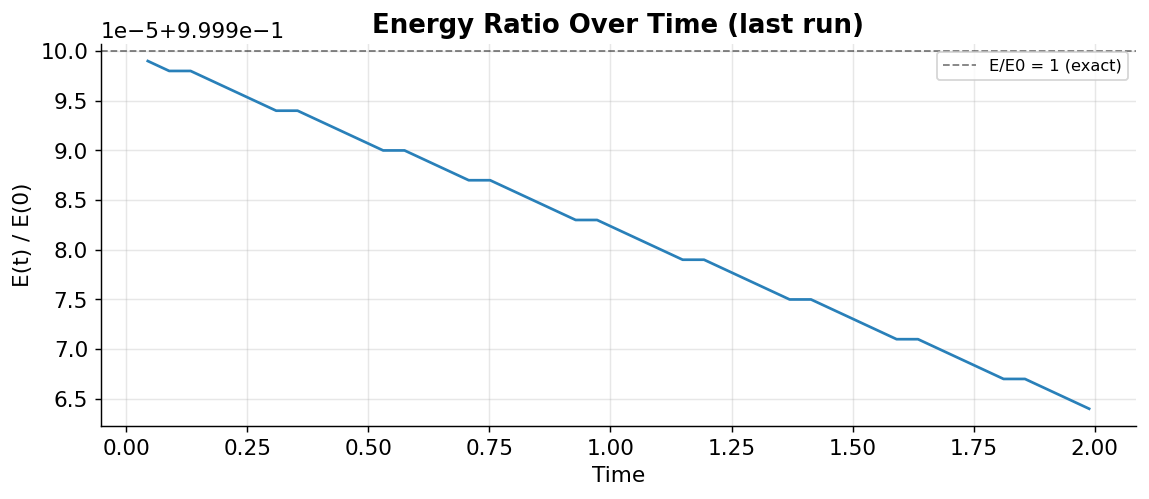

Saved energy_timeseries.png
Final E/E0 = 0.999964


In [2]:
# ── Energy ratio vs time from last run ──
try:
    energy = pd.read_csv(DATA / 'energy.csv')
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(energy['time'], energy['energy_ratio'], lw=1.5, color='#2980b9')
    ax.axhline(1.0, color='k', ls='--', lw=1, alpha=0.5, label='E/E0 = 1 (exact)')
    ax.set_xlabel('Time')
    ax.set_ylabel('E(t) / E(0)')
    ax.set_title('Energy Ratio Over Time (last run)', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(DATA / 'energy_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved energy_timeseries.png')
    print(f'Final E/E0 = {energy["energy_ratio"].iloc[-1]:.6f}')
except FileNotFoundError:
    print('energy.csv not found — run a simulation first')

Loaded 14 dispersion runs
scheme       BE   CN  Leapfrog  RK4
dt                                 
0.002   1.00000  1.0   1.00784  1.0
0.005   1.00003  1.0   1.01973  1.0
0.010   1.00013  1.0   1.03990  1.0
0.020   1.00054  1.0       NaN  NaN


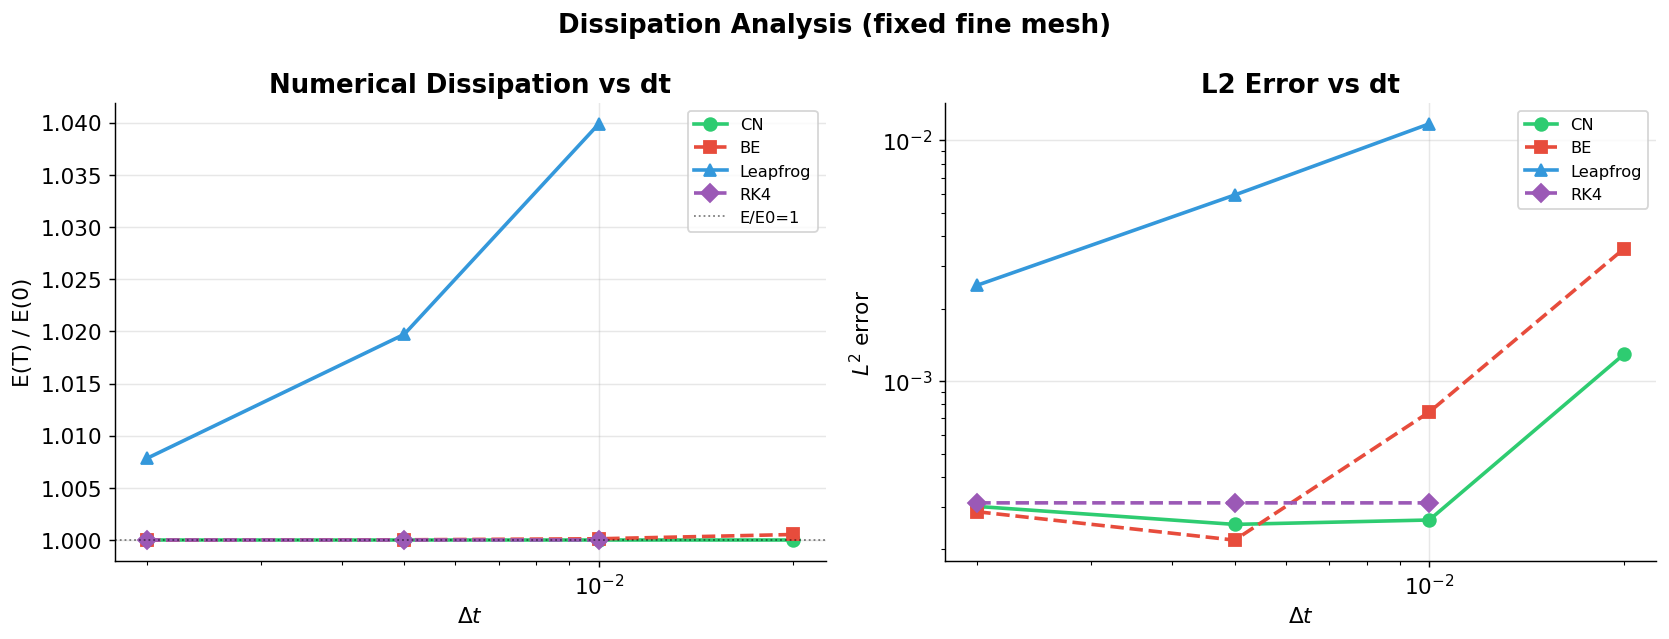

Saved dissipation_analysis.png


In [3]:
# ── E/E0 vs dt for all schemes (dispersion sweep) ──
try:
    disp = pd.read_csv(DATA / 'dispersion_summary.csv')
    print(f'Loaded {len(disp)} dispersion runs')
    print(disp.pivot_table(index='dt', columns='scheme', values='energy_ratio').round(5))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: E/E0 vs dt
    ax = axes[0]
    for scheme, style in STYLE.items():
        s = disp[disp['scheme'] == scheme].sort_values('dt')
        if s.empty: continue
        ax.semilogx(s['dt'], s['energy_ratio'], lw=2, markersize=7, **style)
    ax.axhline(1.0, color='k', ls=':', lw=1, alpha=0.5, label='E/E0=1')
    ax.set_xlabel(r'$\Delta t$')
    ax.set_ylabel('E(T) / E(0)')
    ax.set_title('Numerical Dissipation vs dt', fontweight='bold')
    ax.legend(fontsize=9)

    # Right: L2 error vs dt
    ax = axes[1]
    for scheme, style in STYLE.items():
        s = disp[disp['scheme'] == scheme].sort_values('dt')
        if s.empty: continue
        ax.loglog(s['dt'], s['l2_error'], lw=2, markersize=7, **style)
    ax.set_xlabel(r'$\Delta t$')
    ax.set_ylabel(r'$L^2$ error')
    ax.set_title('L2 Error vs dt', fontweight='bold')
    ax.legend(fontsize=9)

    plt.suptitle('Dissipation Analysis (fixed fine mesh)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(DATA / 'dissipation_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved dissipation_analysis.png')

except FileNotFoundError:
    print('dispersion_summary.csv not found — run scripts/dispersion_sweep.py first')

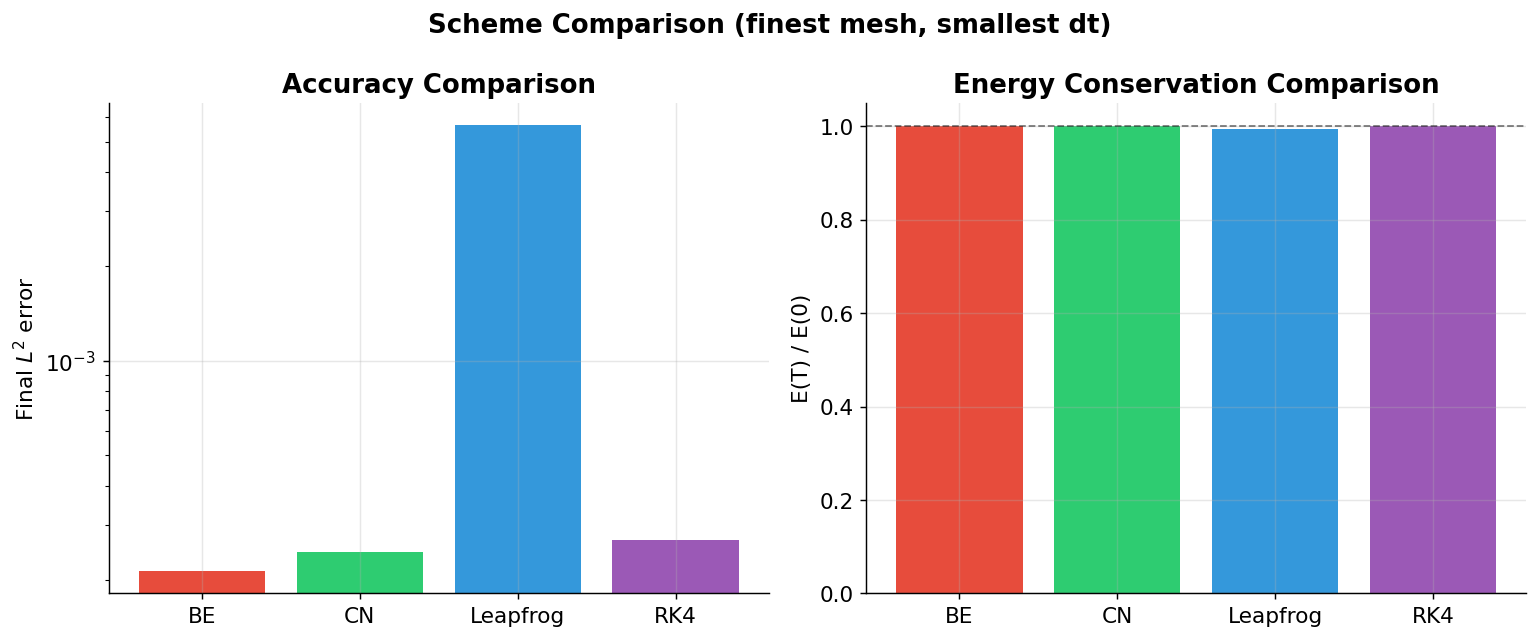

Saved scheme_comparison.png
  scheme  l2_error  energy_ratio  wall_time
      BE  0.000214      1.000029      9.006
      CN  0.000247      1.000000      8.945
Leapfrog  0.005632      0.994508      5.329
     RK4  0.000269      1.000000     12.269


In [4]:
# ── Summary bar chart: final E/E0 and L2 error by scheme ──
# Uses convergence_all.csv — pick a single representative run per scheme
try:
    df = pd.read_csv(DATA / 'convergence_all.csv')
    # Best run: finest ref, smallest dt, Q1
    best = (df[(df['fe_degree'] == 1) & (df['refinements'] == df['refinements'].max())]
            .sort_values('dt')
            .groupby('scheme').first()
            .reset_index())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    colors = [STYLE.get(s, {}).get('color', '#888') for s in best['scheme']]

    axes[0].bar(best['scheme'], best['l2_error'], color=colors)
    axes[0].set_yscale('log')
    axes[0].set_ylabel(r'Final $L^2$ error')
    axes[0].set_title('Accuracy Comparison', fontweight='bold')

    axes[1].bar(best['scheme'], best['energy_ratio'], color=colors)
    axes[1].axhline(1.0, color='k', ls='--', lw=1, alpha=0.5)
    axes[1].set_ylabel('E(T) / E(0)')
    axes[1].set_title('Energy Conservation Comparison', fontweight='bold')

    plt.suptitle('Scheme Comparison (finest mesh, smallest dt)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(DATA / 'scheme_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved scheme_comparison.png')
    print(best[['scheme', 'l2_error', 'energy_ratio', 'wall_time']].to_string(index=False))

except FileNotFoundError:
    print('convergence_all.csv not found')